In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.io import arff
pd.set_option('display.max_columns', None)

In [2]:
data, meta = arff.loadarff("./data/dataset_57_hypothyroid.arff")

train = pd.DataFrame(data)

# byte string → normal string dönüşümü (gerekirse)
for col in train.select_dtypes([object]):
    train[col] = train[col].str.decode("utf-8")

print(train.head())
print(train.shape)

    age sex on_thyroxine query_on_thyroxine on_antithyroid_medication sick  \
0  41.0   F            f                  f                         f    f   
1  23.0   F            f                  f                         f    f   
2  46.0   M            f                  f                         f    f   
3  70.0   F            t                  f                         f    f   
4  70.0   F            f                  f                         f    f   

  pregnant thyroid_surgery I131_treatment query_hypothyroid  \
0        f               f              f                 f   
1        f               f              f                 f   
2        f               f              f                 f   
3        f               f              f                 f   
4        f               f              f                 f   

  query_hyperthyroid lithium goitre tumor hypopituitary psych TSH_measured  \
0                  f       f      f     f             f     f            t

In [3]:
binary_cols = ["on_thyroxine","query_on_thyroxine","on_antithyroid_medication","sick","pregnant","thyroid_surgery","I131_treatment","query_hypothyroid","query_hyperthyroid","lithium","goitre","tumor","hypopituitary","psych","TSH_measured","FTI_measured","TBG_measured"]
numeric_cols = ["age","TSH","T3","TT4","T4U","FTI"]
ohe_cols = ["referral_source"]



for col in binary_cols:
   train[col] = train[col].map({"f": 0, "t": 1})

train["sex"] = train["sex"].map({"F": 0, "M": 1})

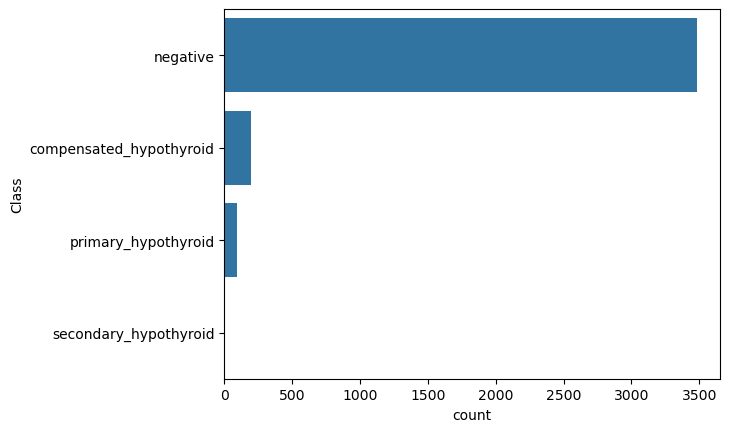

In [4]:
# target analysis
sns.countplot(data=train["Class"]  )
plt.show()

In [5]:
train["Class"].value_counts()

Class
negative                   3481
compensated_hypothyroid     194
primary_hypothyroid          95
secondary_hypothyroid         2
Name: count, dtype: int64

In [6]:
train = train.drop("TBG",axis=1)

In [7]:
train.isnull().sum()

age                            1
sex                          150
on_thyroxine                   0
query_on_thyroxine             0
on_antithyroid_medication      0
sick                           0
pregnant                       0
thyroid_surgery                0
I131_treatment                 0
query_hypothyroid              0
query_hyperthyroid             0
lithium                        0
goitre                         0
tumor                          0
hypopituitary                  0
psych                          0
TSH_measured                   0
TSH                          369
T3_measured                    0
T3                           769
TT4_measured                   0
TT4                          231
T4U_measured                   0
T4U                          387
FTI_measured                   0
FTI                          385
TBG_measured                   0
referral_source                0
Class                          0
dtype: int64

In [8]:
train.isnull().sum(axis=1)

0       0
1       2
2       1
3       2
4       0
       ..
3767    5
3768    0
3769    0
3770    0
3771    0
Length: 3772, dtype: int64

In [9]:
#missing pattern analysis

In [10]:
missing_df = train.isnull().astype(int)

In [11]:
corr = missing_df.corr()

In [23]:
corr[numeric_cols]

,age,TSH,T3,TT4,T4U,FTI
age,1.000000,-0.005362,-0.008241,-0.004159,-0.005506,-0.005490
sex,-0.003314,0.010623,-0.022160,0.027238,0.020613,0.021017
on_thyroxine,NaN,NaN,NaN,NaN,NaN,NaN
query_on_thyroxine,NaN,NaN,NaN,NaN,NaN,NaN
on_antithyroid_medication,NaN,NaN,NaN,NaN,NaN,NaN
sick,NaN,NaN,NaN,NaN,NaN,NaN
pregnant,NaN,NaN,NaN,NaN,NaN,NaN
thyroid_surgery,NaN,NaN,NaN,NaN,NaN,NaN
I131_treatment,NaN,NaN,NaN,NaN,NaN,NaN
query_hypothyroid,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
(missing_df["T4U"]*missing_df["FTI"]).value_counts()

0    3387
1     385
Name: count, dtype: int64

In [29]:
(missing_df["T4U"]*missing_df["FTI"]*missing_df["TT4"] ).value_counts()

0    3544
1     228
Name: count, dtype: int64

In [30]:
(missing_df["T4U"]*missing_df["FTI"]*missing_df["TT4"] * missing_df["TSH"] ).value_counts()

0    3569
1     203
Name: count, dtype: int64

In [31]:
(missing_df["T4U"]*missing_df["FTI"]*missing_df["TT4"] * missing_df["TSH"] * missing_df["T3"] ).value_counts()

0    3593
1     179
Name: count, dtype: int64

/home/msel/miniconda3/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/msel/miniconda3/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


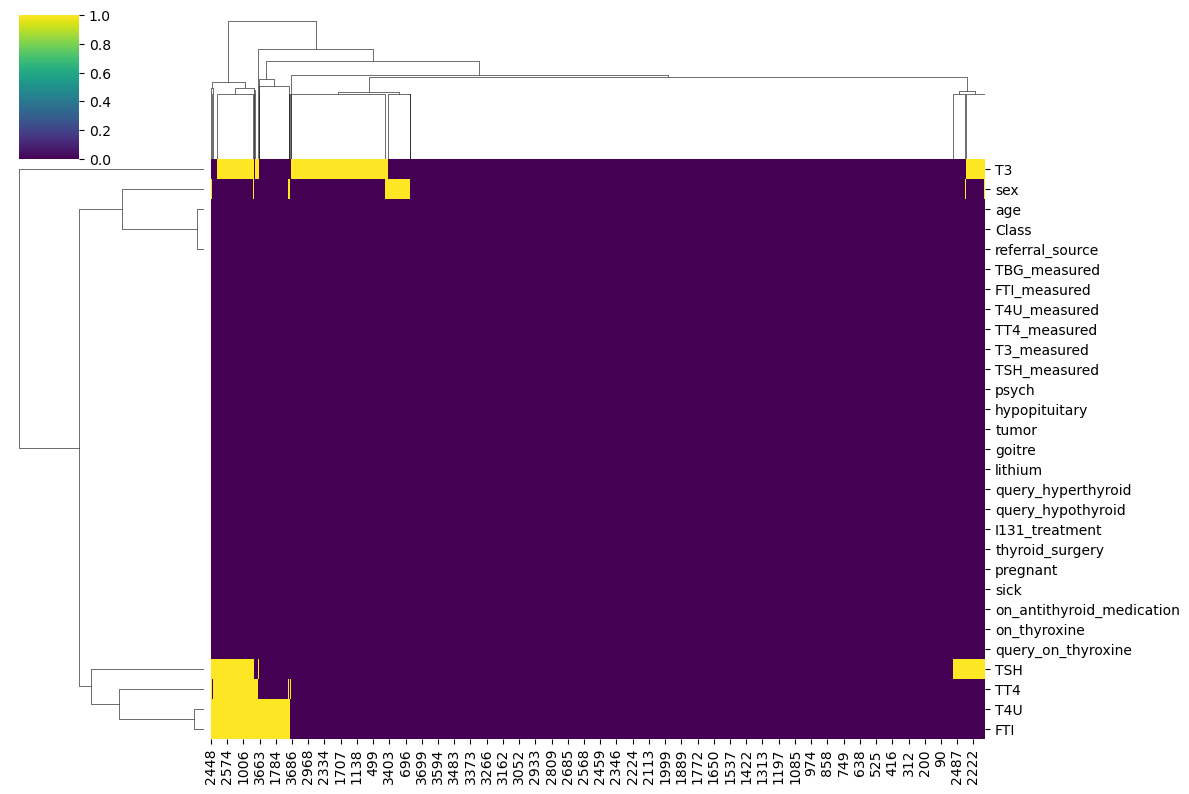

In [13]:
sns.clustermap(missing_df.T, cmap="viridis", figsize=(12,8))

<Axes: >

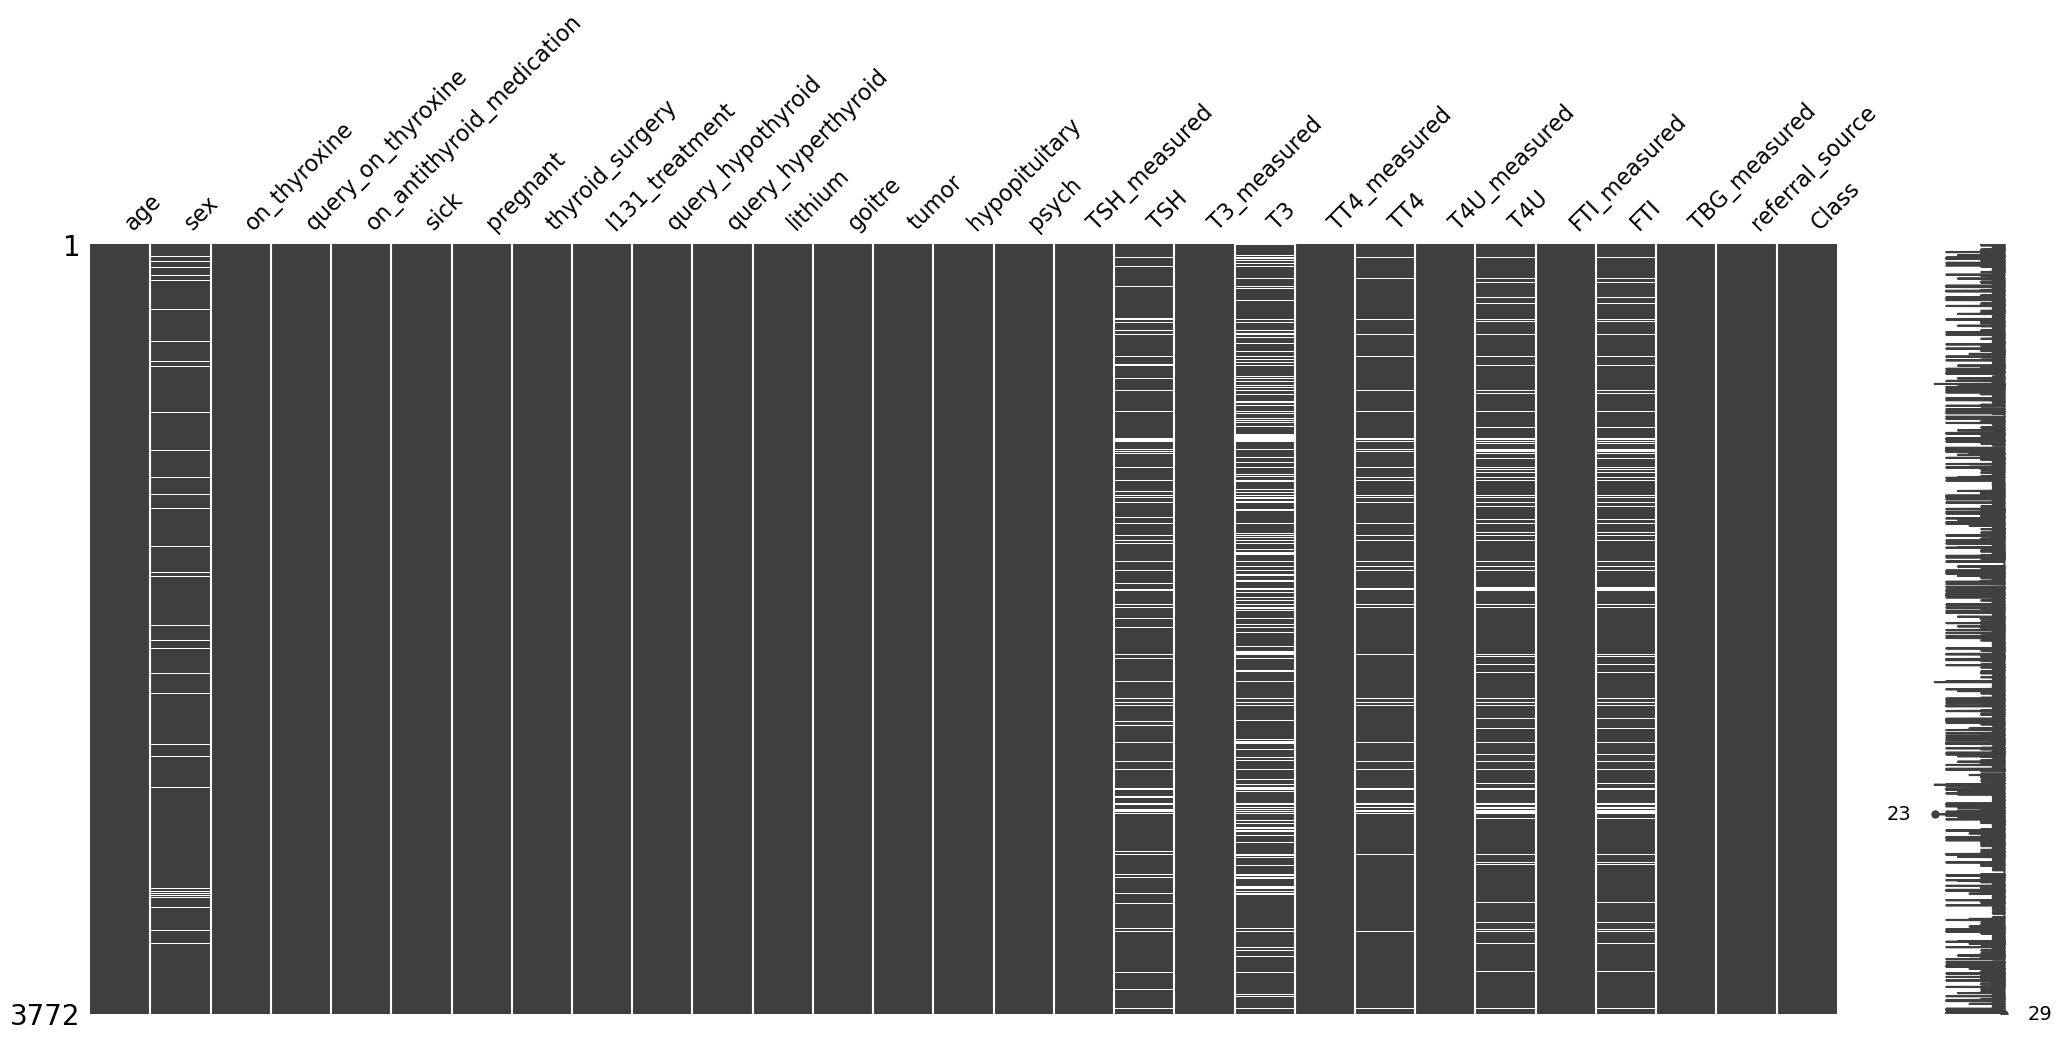

In [18]:

import missingno as msno

msno.matrix(train)


<Axes: >

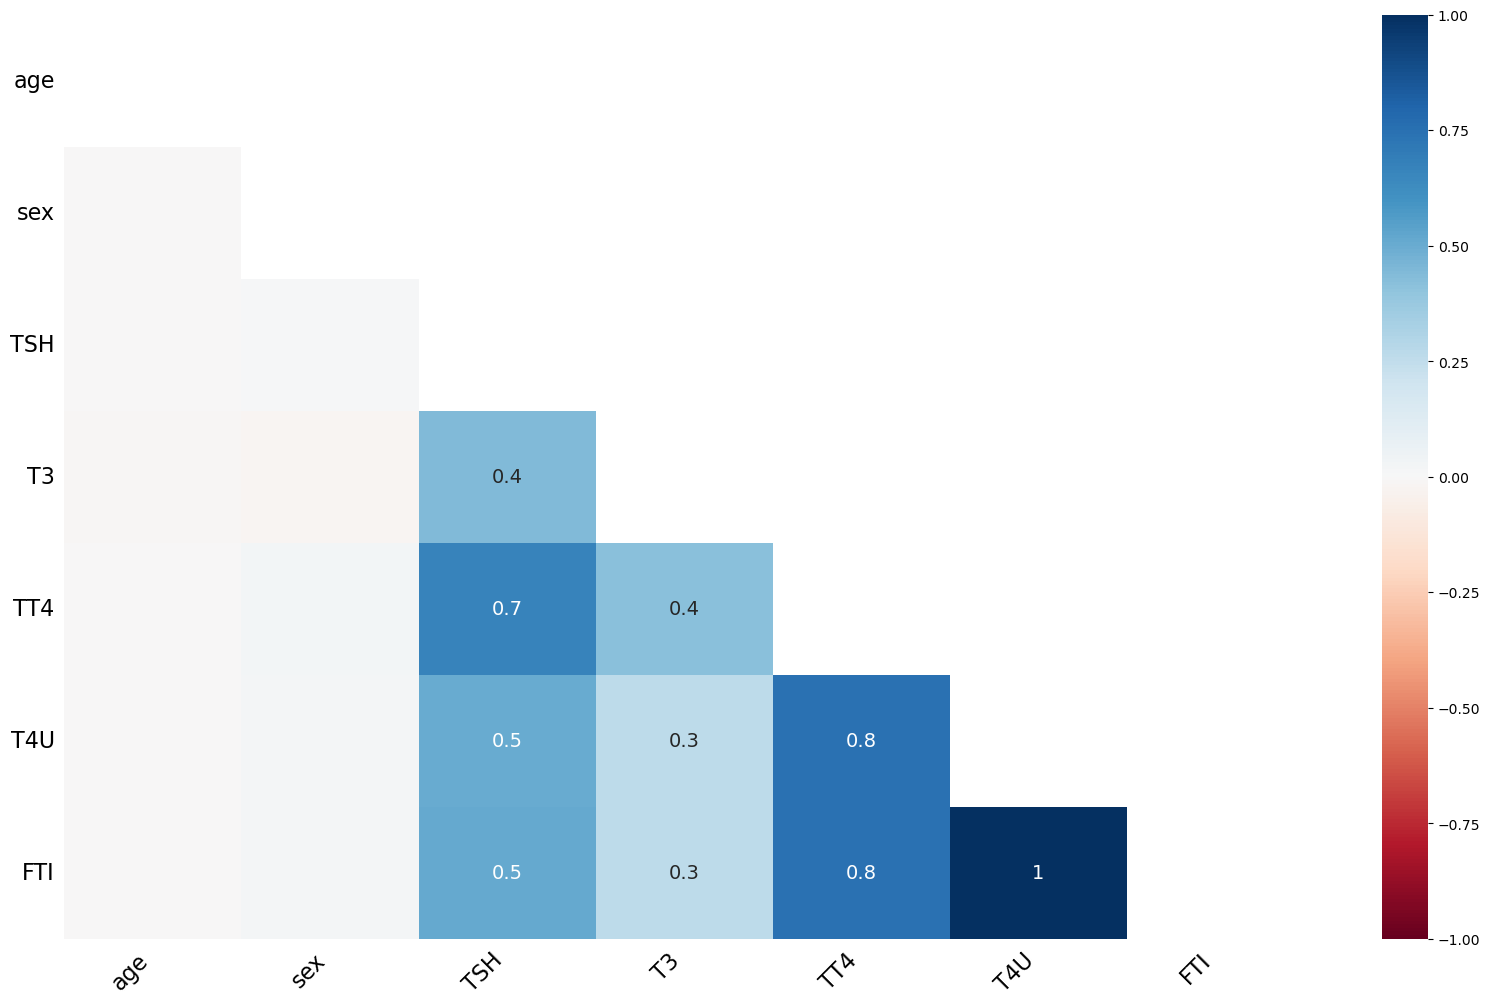

In [19]:
msno.heatmap(train)


<Axes: >

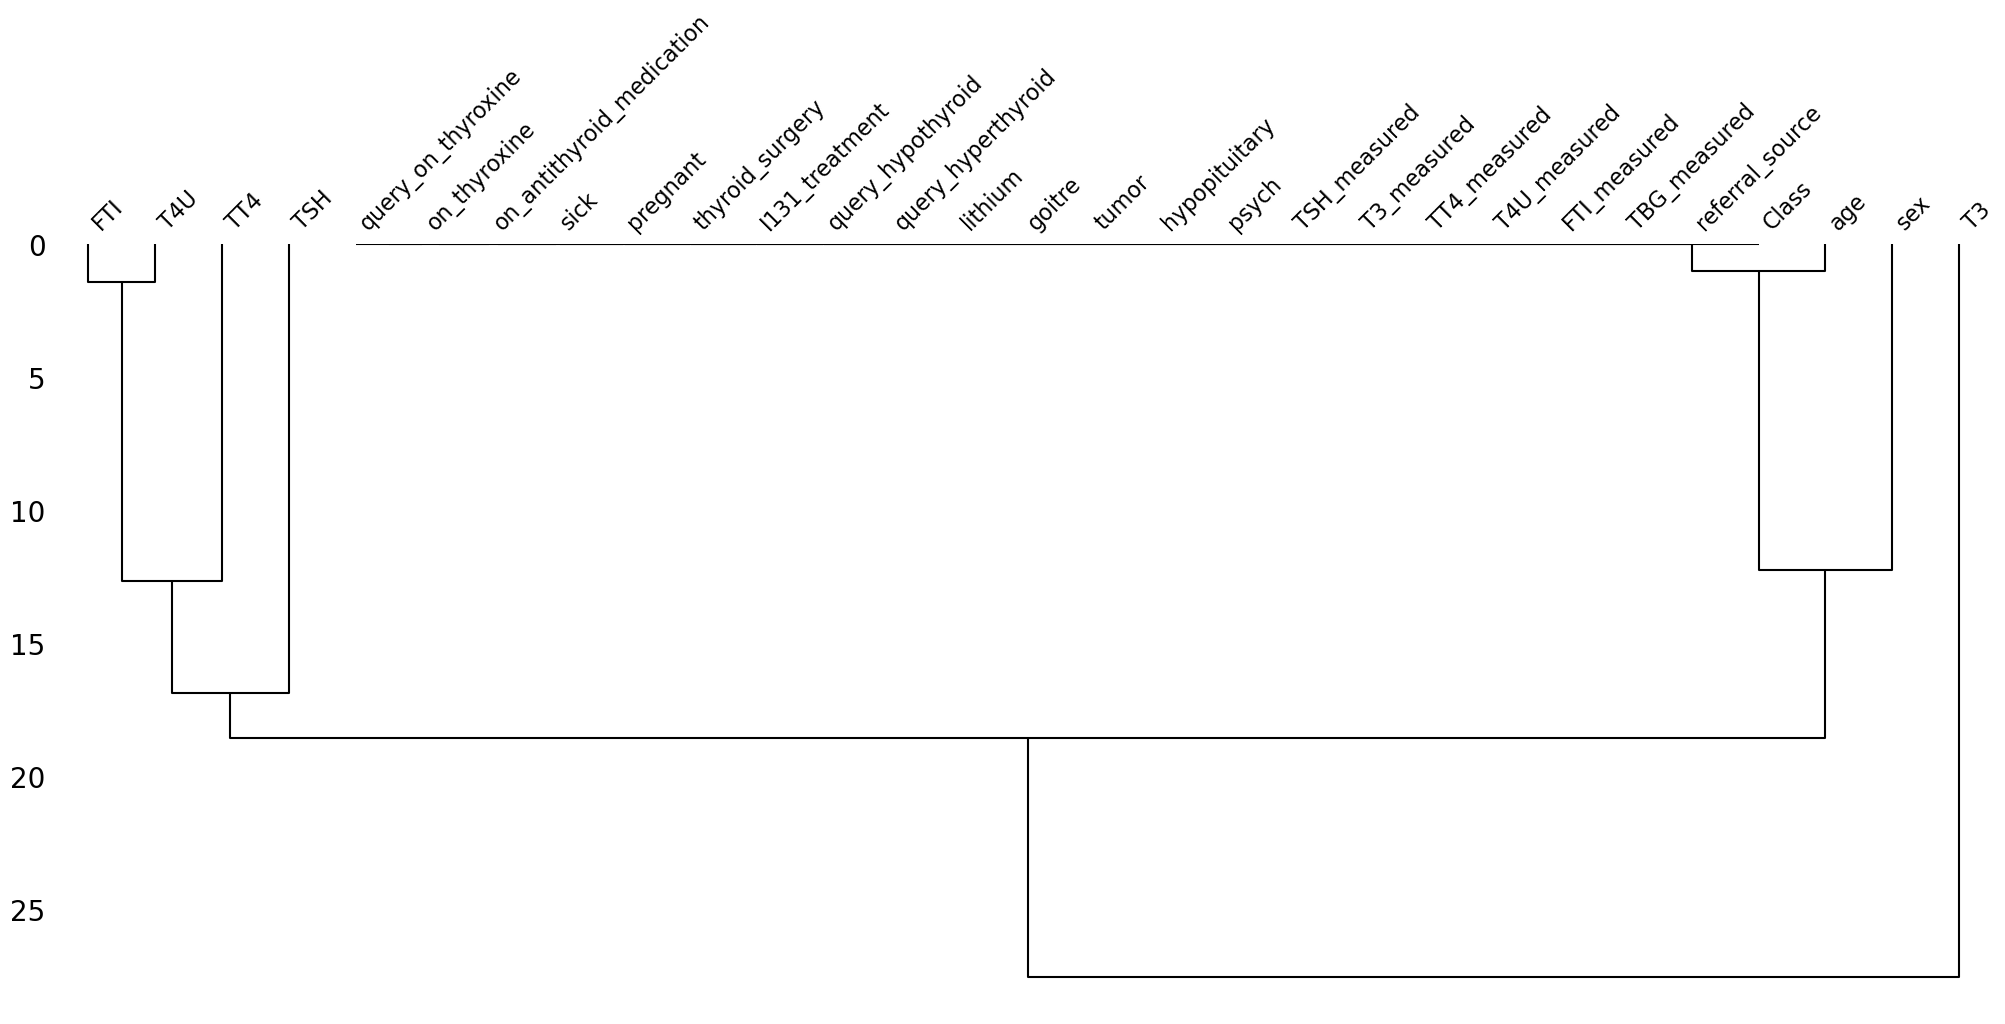

In [20]:
msno.dendrogram(train)

In [32]:
together_missing_cols = ["FTI","T4U"]
train[together_missing_cols]["Class"].mean()

KeyError: 'Class'